<a href="https://colab.research.google.com/github/AndrewNK1/BigData_Startegic_Analytics/blob/main/BigData_%26_NoSQL_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Citi Bike Analytics Project**

**Course: Big Data & NoSQL Databases (Spring 2026)**

**Project Overview**

This notebook implements a comprehensive big data pipeline for a city planning agency in New York using historical Citi Bike trip data. Our objective is to process high-volume ride data to uncover user demographics, predict trip patterns, and provide data-driven recommendations for station expansions. The pipeline covers end-to-end processing, including advanced data cleaning and engineering (handling anomalies, computing geospatial distances via the Haversine formula, and time categorization) , execution of deep analytical business queries , and a SparkML task training multiple classifiers to predict rider gender. All outputs and evaluations are fully rendered within this notebook to fulfill the final project deliverables.

Made by: Andrew Nabil Karam

# **1. Data Cleaning & Engineering:**

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, hour, month, year, unix_timestamp, udf, trim, lit, current_date
from pyspark.sql.types import DoubleType
import math

In [ ]:
# 1.a) Initialize Spark session
spark = SparkSession.builder \
    .appName("CitiBike_Data_Engineering") \
    .getOrCreate()

**1.1 Data Uploading & Intial Standardization**

In [ ]:
import os

# Define the path to your CSV file
csv_path = "/content/citi_data.csv"

# Google Drive file ID for the provided link
google_drive_file_id = "1vDrZYTcZNsbsXdHzBe5fLxlSiIKALCqR"

# Check if the file exists, if not, download it from Google Drive
if not os.path.exists(csv_path):
    print(f"{csv_path} not found. Downloading from Google Drive...")
    # Install gdown if not already installed
    try:
        import gdown
    except ImportError:
        print("gdown not found. Installing...")
        !pip install gdown -qq
        import gdown

    gdown.download(id=google_drive_file_id, output=csv_path, quiet=False)
    print("Download complete.")
else:
    print(f"{csv_path} already exists.")

# Load the CSV file into a Spark DataFrame
df = spark.read.csv(csv_path, header=True, inferSchema=True)

/content/citi_data.csv already exists.


In [ ]:
# Display the schema of the DataFrame
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- starttime: timestamp (nullable = true)
 |-- stoptime: timestamp (nullable = true)
 |-- start station id: double (nullable = true)
 |-- start station name: string (nullable = true)
 |-- start station latitude: double (nullable = true)
 |-- start station longitude: double (nullable = true)
 |-- end station id: double (nullable = true)
 |-- end station name: string (nullable = true)
 |-- end station latitude: double (nullable = true)
 |-- end station longitude: double (nullable = true)
 |-- bikeid: integer (nullable = true)
 |-- usertype: string (nullable = true)
 |-- birth year: integer (nullable = true)
 |-- gender: integer (nullable = true)



In [ ]:
 # Display the first 5 rows to get a glimpse of the data
df.show(5)

+---+--------------------+--------------------+----------------+--------------------+----------------------+-----------------------+--------------+--------------------+--------------------+---------------------+------+----------+----------+------+
|_c0|           starttime|            stoptime|start station id|  start station name|start station latitude|start station longitude|end station id|    end station name|end station latitude|end station longitude|bikeid|  usertype|birth year|gender|
+---+--------------------+--------------------+----------------+--------------------+----------------------+-----------------------+--------------+--------------------+--------------------+---------------------+------+----------+----------+------+
|  0|2019-04-17 14:37:...|2019-04-17 14:43:...|           264.0|Maiden Ln & Pearl St|           40.70706456|           -74.00731853|         330.0| Reade St & Broadway|         40.71450451|         -74.00562789| 16906|Subscriber|      1969|     1|
|  1|201

In [ ]:
# Display summary statistics for numerical columns
df.describe().show()

+-------+-----------------+------------------+--------------------+----------------------+-----------------------+------------------+--------------------+--------------------+---------------------+------------------+----------+------------------+------------------+
|summary|              _c0|  start station id|  start station name|start station latitude|start station longitude|    end station id|    end station name|end station latitude|end station longitude|            bikeid|  usertype|        birth year|            gender|
+-------+-----------------+------------------+--------------------+----------------------+-----------------------+------------------+--------------------+--------------------+---------------------+------------------+----------+------------------+------------------+
|  count|          1300000|           1299967|             1299967|               1300000|                1300000|           1299967|             1299967|             1300000|              1300000|     

In [ ]:
for column in df.columns:
    new_column_name = column.replace(' ', '_')
    df = df.withColumnRenamed(column, new_column_name)

print("Columns renamed with underscores.")

Columns renamed with underscores.


In [ ]:
from pyspark.sql.functions import col, when, count

df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

+---+---------+--------+----------------+------------------+----------------------+-----------------------+--------------+----------------+--------------------+---------------------+------+--------+----------+------+
|_c0|starttime|stoptime|start_station_id|start_station_name|start_station_latitude|start_station_longitude|end_station_id|end_station_name|end_station_latitude|end_station_longitude|bikeid|usertype|birth_year|gender|
+---+---------+--------+----------------+------------------+----------------------+-----------------------+--------------+----------------+--------------------+---------------------+------+--------+----------+------+
|  0|        0|       0|              33|                33|                     0|                      0|            33|              33|                   0|                    0|     0|       0|         0|     0|
+---+---------+--------+----------------+------------------+----------------------+-----------------------+--------------+----------

**1.2 Handling Nulls & Duplicates**

In [ ]:
cleaned_df = df
initial_row_count = cleaned_df.count()

# Drop rows where any column is null
cleaned_df = cleaned_df.dropna()
print(f"Initial row count: {initial_row_count}")
print(f"Row count after dropping nulls: {cleaned_df.count()}")

# Filter out rows where essential string columns are empty or relevant numerical IDs/birth_year are zero
rows_after_nulls = cleaned_df.count()
cleaned_df = cleaned_df.filter(
    (col("start_station_name") != "") &
    (col("end_station_name") != "") &
    (col("usertype") != "") &
    (col("start_station_id") != 0) &
    (col("end_station_id") != 0) &
    (col("bikeid") != 0) &
    (col("birth_year") != 0)
)
print(f"Row count after dropping empty strings and zeros in essential fields: {cleaned_df.count()}")

# Verify null counts after all dropping/filtering
from pyspark.sql.functions import col, when, count, lit

print("\nNull counts after all cleaning steps:")
cleaned_df.select([count(when(col(c).isNull(), c)).alias(c) for c in cleaned_df.columns]).show()

print("\nEmpty string counts after all cleaning steps (for essential string columns):")
cleaned_df.select(
    count(when(col("start_station_name") == "", 1)).alias("empty_start_station_name"),
    count(when(col("end_station_name") == "", 1)).alias("empty_end_station_name"),
    count(when(col("usertype") == "", 1)).alias("empty_usertype")
).show()

print("\nZero counts after all cleaning steps (for essential ID and birth year columns):")
cleaned_df.select(
    count(when(col("start_station_id") == 0, 1)).alias("zero_start_station_id"),
    count(when(col("end_station_id") == 0, 1)).alias("zero_end_station_id"),
    count(when(col("bikeid") == 0, 1)).alias("zero_bikeid"),
    count(when(col("birth_year") == 0, 1)).alias("zero_birth_year")
).show()

Initial row count: 1300000
Row count after dropping nulls: 1299967
Row count after dropping empty strings and zeros in essential fields: 1299967

Null counts after all cleaning steps:
+---+---------+--------+----------------+------------------+----------------------+-----------------------+--------------+----------------+--------------------+---------------------+------+--------+----------+------+
|_c0|starttime|stoptime|start_station_id|start_station_name|start_station_latitude|start_station_longitude|end_station_id|end_station_name|end_station_latitude|end_station_longitude|bikeid|usertype|birth_year|gender|
+---+---------+--------+----------------+------------------+----------------------+-----------------------+--------------+----------------+--------------------+---------------------+------+--------+----------+------+
|  0|        0|       0|               0|                 0|                     0|                      0|             0|               0|                   0|     

In [ ]:
total_rows = cleaned_df.count()
distinct_rows = cleaned_df.distinct().count()

print(f"Total number of rows: {total_rows}")
print(f"Number of distinct rows: {distinct_rows}")

if total_rows == distinct_rows:
    print("No duplicate rows found.")
else:
    num_duplicates = total_rows - distinct_rows
    print(f"Detected {num_duplicates} duplicate row(s).")


Total number of rows: 1299967
Number of distinct rows: 1299967
No duplicate rows found.


**1.3 Standardize 'gender' values**

In [ ]:
# Map 'gender' values (0: Unknown, 1: Male, 2: Female)
cleaned_df = cleaned_df.withColumn("gender",
                                   when(col("gender") == 0, "Unknown")
                                   .when(col("gender") == 1, "Male")
                                   .when(col("gender") == 2, "Female")
                                   .otherwise(lit(None)))

print("Gender values standardized.")
cleaned_df.groupBy("gender").count().show()

Gender values standardized.
+-------+------+
| gender| count|
+-------+------+
| Female|312247|
|Unknown|101483|
|   Male|886237|
+-------+------+




Let's review the schema and summary statistics of the cleaned DataFrame to confirm the changes.

In [ ]:
# Display the schema of the cleaned DataFrame
cleaned_df.printSchema()

# Display summary statistics for numerical columns of the cleaned DataFrame
cleaned_df.describe().show()

# Display the first 5 rows to see the cleaned data
cleaned_df.show(5)

root
 |-- _c0: integer (nullable = true)
 |-- starttime: timestamp (nullable = true)
 |-- stoptime: timestamp (nullable = true)
 |-- start_station_id: double (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_latitude: double (nullable = true)
 |-- start_station_longitude: double (nullable = true)
 |-- end_station_id: double (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_latitude: double (nullable = true)
 |-- end_station_longitude: double (nullable = true)
 |-- bikeid: integer (nullable = true)
 |-- usertype: string (nullable = true)
 |-- birth_year: integer (nullable = true)
 |-- gender: string (nullable = true)

+-------+-----------------+------------------+--------------------+----------------------+-----------------------+------------------+--------------------+--------------------+---------------------+-----------------+----------+------------------+-------+
|summary|              _c0|  start_station_id|  sta

**1.4 Feature Engineering**

Now, let's create new columns that provide useful insights based on the existing data.

Rider Age

We will derive an `age` column using the `birth_year` and the current year. We will set age to `NULL` if `birth_year` is `NULL`.

In [ ]:
# Calculate Rider Age
# Assuming trips are from the current year for age calculation (using current_date())
# Note: A more precise approach would use the year of 'starttime' for each trip
cleaned_df = cleaned_df.withColumn("age",
                                   when(col("birth_year").isNotNull(), year(current_date()) - col("birth_year"))
                                   .otherwise(lit(None)))

print("Rider Age column created.")
cleaned_df.select("birth_year", "age").show(5)

Rider Age column created.
+----------+---+
|birth_year|age|
+----------+---+
|      1969| 57|
|      1974| 52|
|      1969| 57|
|      1986| 40|
|      1979| 47|
+----------+---+
only showing top 5 rows


Trip Duration

Calculate the duration of each trip in seconds.

In [ ]:
# Calculate Trip Duration in seconds
cleaned_df = cleaned_df.withColumn("trip_duration_seconds",
                                   unix_timestamp(col("stoptime")) - unix_timestamp(col("starttime")))

print("Trip Duration column created.")
cleaned_df.select("starttime", "stoptime", "trip_duration_seconds").show(5)

Trip Duration column created.
+--------------------+--------------------+---------------------+
|           starttime|            stoptime|trip_duration_seconds|
+--------------------+--------------------+---------------------+
|2019-04-17 14:37:...|2019-04-17 14:43:...|                  370|
|2019-04-17 14:37:...|2019-04-17 14:42:...|                  347|
|2019-04-17 14:37:...|2019-04-17 14:52:...|                  919|
|2019-04-17 14:37:...|2019-04-17 14:46:...|                  591|
|2019-04-17 14:37:...|2019-04-17 14:42:...|                  331|
+--------------------+--------------------+---------------------+
only showing top 5 rows


Trip Distance (Haversine Formula)

Calculate the estimated trip distance using the Haversine formula based on start and end station coordinates. This requires a UDF for the calculation.

In [ ]:
# Haversine formula to calculate distance between two lat/lon points
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of Earth in kilometers

    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)

    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad

    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    distance = R * c
    return distance

# Register UDF
haversine_udf = udf(haversine_distance, DoubleType())

# Calculate Trip Distance
cleaned_df = cleaned_df.withColumn("trip_distance_km",
                                   haversine_udf(
                                       col("start_station_latitude"),
                                       col("start_station_longitude"),
                                       col("end_station_latitude"),
                                       col("end_station_longitude")
                                   ))

print("Trip Distance (km) column created.")
cleaned_df.select("start_station_latitude", "start_station_longitude",
                  "end_station_latitude", "end_station_longitude",
                  "trip_distance_km").show(5)

Trip Distance (km) column created.
+----------------------+-----------------------+--------------------+---------------------+------------------+
|start_station_latitude|start_station_longitude|end_station_latitude|end_station_longitude|  trip_distance_km|
+----------------------+-----------------------+--------------------+---------------------+------------------+
|           40.70706456|           -74.00731853|         40.71450451|         -74.00562789|0.8394676548008194|
|           40.72228087|           -73.97668709|         40.72779126|         -73.98564945|0.9725410537635828|
|           40.72710258|           -74.00297088|         40.73291553|         -74.00711384|0.7346180002081097|
|           40.71850211|           -73.98329859|           40.718822|            -73.99596|1.0676592264973912|
|            40.7527085|            -73.9397405|           40.757186|           -73.932719|0.7730897713722799|
+----------------------+-----------------------+--------------------+--------

Trip Speed (Km/h)

Calculate an estimated speed using the trip distance and trip duration. Handle cases where `trip_duration_seconds` is zero to avoid division by zero errors.

In [ ]:
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

# Define a UDF for calculating trip speed (Km/h) with conversion
def calculate_trip_speed_udf(distance_km, duration_seconds):
    if duration_seconds is None or duration_seconds <= 0:
        return 0.0
    return (distance_km / duration_seconds) * 3600

# Register the UDF
trip_speed_udf_func = udf(calculate_trip_speed_udf, DoubleType())

# Calculate Trip Speed (Km/h) using the UDF
cleaned_df = cleaned_df.withColumn("trip_speed_kmh_udf",
                                   trip_speed_udf_func(
                                       col("trip_distance_km"),
                                       col("trip_duration_seconds")
                                   ))

print("Trip Speed (Km/h) column created using UDF.")
cleaned_df.select("trip_distance_km", "trip_duration_seconds", "trip_speed_kmh_udf").show(5)

Trip Speed (Km/h) column created using UDF.
+------------------+---------------------+------------------+
|  trip_distance_km|trip_duration_seconds|trip_speed_kmh_udf|
+------------------+---------------------+------------------+
|0.8394676548008194|                  370| 8.167793398062027|
|0.9725410537635828|                  347|10.089763093800858|
|0.7346180002081097|                  919|2.8777201313919423|
|1.0676592264973912|                  591| 6.503507978664312|
|0.7730897713722799|                  331| 8.408227120665279|
+------------------+---------------------+------------------+
only showing top 5 rows


Time Categorization (Period_of_Day)

Create a `Period_of_Day` feature (Morning, Afternoon, Evening, Night) based on the `starttime`.

In [ ]:
# Create Period_of_Day feature
cleaned_df = cleaned_df.withColumn("period_of_day",
                                   when((hour(col("starttime")) >= 5) & (hour(col("starttime")) < 12), "Morning")
                                   .when((hour(col("starttime")) >= 12) & (hour(col("starttime")) < 17), "Afternoon")
                                   .when((hour(col("starttime")) >= 17) & (hour(col("starttime")) < 21), "Evening")
                                   .otherwise("Night"))

print("Period of Day column created.")
cleaned_df.select("starttime", hour(col("starttime")).alias("start_hour"), "period_of_day").show(5)
cleaned_df.groupBy("period_of_day").count().show()

Period of Day column created.
+--------------------+----------+-------------+
|           starttime|start_hour|period_of_day|
+--------------------+----------+-------------+
|2019-04-17 14:37:...|        14|    Afternoon|
|2019-04-17 14:37:...|        14|    Afternoon|
|2019-04-17 14:37:...|        14|    Afternoon|
|2019-04-17 14:37:...|        14|    Afternoon|
|2019-04-17 14:37:...|        14|    Afternoon|
+--------------------+----------+-------------+
only showing top 5 rows
+-------------+------+
|period_of_day| count|
+-------------+------+
|      Evening|336966|
|      Morning|433531|
|    Afternoon|438090|
|        Night| 91380|
+-------------+------+



Start Month

Extract the `start_month` from the `starttime`.

In [ ]:
# Extract Start Month
cleaned_df = cleaned_df.withColumn("start_month", month(col("starttime")))

print("Start Month column created.")
cleaned_df.select("starttime", "start_month").show(5)

Start Month column created.
+--------------------+-----------+
|           starttime|start_month|
+--------------------+-----------+
|2019-04-17 14:37:...|          4|
|2019-04-17 14:37:...|          4|
|2019-04-17 14:37:...|          4|
|2019-04-17 14:37:...|          4|
|2019-04-17 14:37:...|          4|
+--------------------+-----------+
only showing top 5 rows


1.5 Final Review of Feature Engineered Data

Let's review the schema and a sample of the DataFrame with all the newly created features.

In [ ]:
cleaned_df.printSchema()

# Display a sample of the DataFrame with new columns
cleaned_df.select("age", "trip_duration_seconds", "trip_distance_km",
                  "trip_speed_kmh_udf", "period_of_day", "start_month").show(5)

root
 |-- _c0: integer (nullable = true)
 |-- starttime: timestamp (nullable = true)
 |-- stoptime: timestamp (nullable = true)
 |-- start_station_id: double (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_latitude: double (nullable = true)
 |-- start_station_longitude: double (nullable = true)
 |-- end_station_id: double (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_latitude: double (nullable = true)
 |-- end_station_longitude: double (nullable = true)
 |-- bikeid: integer (nullable = true)
 |-- usertype: string (nullable = true)
 |-- birth_year: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- trip_duration_seconds: long (nullable = true)
 |-- trip_distance_km: double (nullable = true)
 |-- trip_speed_kmh_udf: double (nullable = true)
 |-- period_of_day: string (nullable = false)
 |-- start_month: integer (nullable = true)

+---+---------------------+---

**1.6 Identifying and Flagging Noisy Records**

Flagging Trips with Short Duration

Flag trips with a `trip_duration_seconds` of less than 60 seconds.

In [ ]:
# Flag trips with duration < 60 seconds
cleaned_df = cleaned_df.withColumn("is_short_trip", col("trip_duration_seconds") < 60)

print("Flagged short duration trips.")
cleaned_df.select("trip_duration_seconds", "is_short_trip").orderBy("trip_duration_seconds").show(5)

Flagged short duration trips.
+---------------------+-------------+
|trip_duration_seconds|is_short_trip|
+---------------------+-------------+
|                   61|        false|
|                   61|        false|
|                   61|        false|
|                   61|        false|
|                   61|        false|
+---------------------+-------------+
only showing top 5 rows


Flagging Trips with Excessive Speed

Flag trips where the calculated speed (`trip_speed_kmh`) exceeds 40 km/h.

In [ ]:
from pyspark.sql import Row
from pyspark.sql.functions import max, col, when, udf
from pyspark.sql.types import DoubleType
import math

# 1. Define Haversine Function
def haversine_distance_safe(lat1, lon1, lat2, lon2):
    if any(v is None for v in [lat1, lon1, lat2, lon2]): return None
    R = 6371
    lat1_rad, lon1_rad = math.radians(lat1), math.radians(lon1)
    lat2_rad, lon2_rad = math.radians(lat2), math.radians(lon2)
    dlon, dlat = lon2_rad - lon1_rad, lat2_rad - lat1_rad
    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    return R * (2 * math.atan2(math.sqrt(a), math.sqrt(1 - a)))

haversine_udf = udf(haversine_distance_safe, DoubleType())

# 2. Add speed columns to cleaned_df
cleaned_df = cleaned_df.withColumn("trip_distance_km", haversine_udf(col("start_station_latitude"), col("start_station_longitude"), col("end_station_latitude"), col("end_station_longitude")))
cleaned_df = cleaned_df.withColumn("trip_speed_kmh", when(col("trip_duration_seconds") > 0, (col("trip_distance_km") / col("trip_duration_seconds")) * 3600).otherwise(0.0))

# 3. SYNTHETIC GLITCH: Inject one fake row with 100km/h speed to demonstrate the fix
fake_row = cleaned_df.limit(1).withColumn("trip_speed_kmh", lit(100.0))
test_df = cleaned_df.union(fake_row)

# 4. Apply the Flagging Logic
test_df = test_df.withColumn("is_overspeed_trip", col("trip_speed_kmh") > 40)

# 5. Show results
print("Overspeed Glitch Detection Report:")
overspeed_count = test_df.filter(col("is_overspeed_trip") == True).count()
if overspeed_count > 0:
    print(f"Success: Detected {overspeed_count} trips exceeding 40 km/h (including test record):")
    test_df.select("trip_distance_km", "trip_duration_seconds", "trip_speed_kmh", "is_overspeed_trip").filter(col("is_overspeed_trip") == True).show()
else:
    print("No trips exceeded 40 km/h in this dataset.")

# Update actual cleaned_df with the logic
cleaned_df = cleaned_df.withColumn("is_overspeed_trip", col("trip_speed_kmh") > 40)

Overspeed Glitch Detection Report:
Success: Detected 2 trips exceeding 40 km/h (including test record):
+------------------+---------------------+------------------+-----------------+
|  trip_distance_km|trip_duration_seconds|    trip_speed_kmh|is_overspeed_trip|
+------------------+---------------------+------------------+-----------------+
| 6.974358599964661|                  474|52.969812151630336|             true|
|0.8394676548008194|                  370|             100.0|             true|
+------------------+---------------------+------------------+-----------------+



Flagging Age Outliers

Flag records where the rider's age is over 100 years or under 12 years.

In [ ]:
# Flag age outliers (over 100 or under 12)
cleaned_df = cleaned_df.withColumn("is_age_outlier",
                                   (col("age").isNotNull()) & ((col("age") > 100) | (col("age") < 12)))

print("Flagged age outliers.")
cleaned_df.select("birth_year", "age", "is_age_outlier").filter(col("is_age_outlier") == True).show(5)

Flagged age outliers.
+----------+---+--------------+
|birth_year|age|is_age_outlier|
+----------+---+--------------+
|      1901|125|          true|
|      1900|126|          true|
|      1900|126|          true|
|      1921|105|          true|
|      1888|138|          true|
+----------+---+--------------+
only showing top 5 rows


Flagging Missing Essential Identifiers

Flag rows missing essential identifiers such as `start_station_name`, `end_station_name`, or `bikeid`.

In [ ]:
# Flag rows with missing essential identifiers
cleaned_df = cleaned_df.withColumn("is_missing_essential_id",
                                   col("start_station_name").isNull() |
                                   col("end_station_name").isNull() |
                                   col("bikeid").isNull())

print("Flagged records with missing essential identifiers.")
cleaned_df.select("start_station_name", "end_station_name", "bikeid", "is_missing_essential_id").filter(col("is_missing_essential_id") == True).show(5)

Flagged records with missing essential identifiers.
+------------------+----------------+------+-----------------------+
|start_station_name|end_station_name|bikeid|is_missing_essential_id|
+------------------+----------------+------+-----------------------+
+------------------+----------------+------+-----------------------+



Review Flagged Records Count


In [ ]:
# Display counts of each flag
print("Count of short trips:", cleaned_df.filter(col("is_short_trip") == True).count())
print("Count of overspeed trips:", cleaned_df.filter(col("is_overspeed_trip") == True).count())
print("Count of age outliers:", cleaned_df.filter(col("is_age_outlier") == True).count())
print("Count of records with missing essential IDs:", cleaned_df.filter(col("is_missing_essential_id") == True).count())

Count of short trips: 0
Count of overspeed trips: 1
Count of age outliers: 716
Count of records with missing essential IDs: 0


Final Schema with Flags


In [ ]:
# Display the final schema
cleaned_df.printSchema()

# Display a sample of the DataFrame including new flag columns
cleaned_df.select("trip_duration_seconds", "is_short_trip",
                  "trip_speed_kmh", "is_overspeed_trip",
                  "age", "is_age_outlier",
                  "start_station_name", "end_station_name", "bikeid", "is_missing_essential_id").show(5)

root
 |-- _c0: integer (nullable = true)
 |-- starttime: timestamp (nullable = true)
 |-- stoptime: timestamp (nullable = true)
 |-- start_station_id: double (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_latitude: double (nullable = true)
 |-- start_station_longitude: double (nullable = true)
 |-- end_station_id: double (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_latitude: double (nullable = true)
 |-- end_station_longitude: double (nullable = true)
 |-- bikeid: integer (nullable = true)
 |-- usertype: string (nullable = true)
 |-- birth_year: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- trip_duration_seconds: long (nullable = true)
 |-- trip_distance_km: double (nullable = true)
 |-- trip_speed_kmh_udf: double (nullable = true)
 |-- period_of_day: string (nullable = false)
 |-- start_month: integer (nullable = true)
 |-- is_short_trip: boolean (nu

Separating Noisy Records



In [ ]:
# Identify noisy records based on any of the flags
noisy_data = cleaned_df.filter(
    (col("is_short_trip") == True) |
    (col("is_overspeed_trip") == True) |
    (col("is_age_outlier") == True) |
    (col("is_missing_essential_id") == True)
)

# Remove noisy records from cleaned_df
cleaned_df = cleaned_df.filter(
    (col("is_short_trip") == False) &
    (col("is_overspeed_trip") == False) &
    (col("is_age_outlier") == False) &
    (col("is_missing_essential_id") == False)
)

print(f"Total noisy records identified: {noisy_data.count()}")
print(f"Remaining clean records in cleaned_df: {cleaned_df.count()}")

print("\nSample of noisy data:")
noisy_data.show(5)

print("\nSample of cleaned_df after removing noisy data:")
cleaned_df.show(5)

Total noisy records identified: 717
Remaining clean records in cleaned_df: 1299250

Sample of noisy data:
+-----+--------------------+--------------------+----------------+--------------------+----------------------+-----------------------+--------------+-------------------+--------------------+---------------------+------+----------+----------+-------+---+---------------------+------------------+------------------+-------------+-----------+-------------+------------------+-----------------+--------------+-----------------------+
|  _c0|           starttime|            stoptime|start_station_id|  start_station_name|start_station_latitude|start_station_longitude|end_station_id|   end_station_name|end_station_latitude|end_station_longitude|bikeid|  usertype|birth_year| gender|age|trip_duration_seconds|  trip_distance_km|trip_speed_kmh_udf|period_of_day|start_month|is_short_trip|    trip_speed_kmh|is_overspeed_trip|is_age_outlier|is_missing_essential_id|
+-----+--------------------+------

# **2. Analytical Queries using Spark SQL**

### Query A: Round Trip Percentage per User Type
This query calculates the proportion of trips where the start and end stations are identical, broken down by user category.

In [ ]:
cleaned_df.createOrReplaceTempView("citi_bike_trips")

In [ ]:
query_a = """
SELECT
    usertype,
    count(*) as total_trips,
    sum(CASE WHEN start_station_id = end_station_id THEN 1 ELSE 0 END) as round_trips,
    round((sum(CASE WHEN start_station_id = end_station_id THEN 1 ELSE 0 END) / count(*)) * 100, 2) as round_trip_percentage
FROM citi_bike_trips
GROUP BY usertype
"""
spark.sql(query_a).show()

+----------+-----------+-----------+---------------------+
|  usertype|total_trips|round_trips|round_trip_percentage|
+----------+-----------+-----------+---------------------+
|Subscriber|    1115501|      17958|                 1.61|
|  Customer|     183749|       9737|                  5.3|
+----------+-----------+-----------+---------------------+



### Business Interpretation of Query A: Round Trip Percentage per User Type

Casual customers have a significantly higher round-trip rate (5.3%) compared to subscribers (1.6%). This indicates customers use bikes for recreational, return-to-start trips, while subscribers prefer one-way commutes. This insight helps optimize station placement for different user types, tailor pricing models (e.g., day passes), and focus marketing efforts (recreation for customers, commuting for subscribers).

### Query B: Popular Start Station Rankings
This query identifies the most popular start stations and uses the `RANK()` window function to order them by popularity.

In [ ]:
query_b = """
SELECT
    start_station_name,
    count(*) as trip_count,
    RANK() OVER (ORDER BY count(*) DESC) as popularity_rank
FROM citi_bike_trips
GROUP BY start_station_name
ORDER BY popularity_rank
LIMIT 10
"""
spark.sql(query_b).show()

+--------------------+----------+---------------+
|  start_station_name|trip_count|popularity_rank|
+--------------------+----------+---------------+
|Pershing Square N...|      9761|              1|
|     8 Ave & W 31 St|      8000|              2|
|  E 17 St & Broadway|      7523|              3|
|  Broadway & E 22 St|      7041|              4|
|     W 21 St & 6 Ave|      7011|              5|
|  Broadway & E 14 St|      6973|              6|
|West St & Chamber...|      6731|              7|
|  Broadway & W 60 St|      6596|              8|
|Christopher St & ...|      6557|              9|
|    12 Ave & W 40 St|      6445|             10|
+--------------------+----------+---------------+



### Business Interpretation of Query B: Popular Start Station Rankings

Identifying the top 10 most popular start stations helps optimize bike distribution and maintenance schedules. High-demand areas require more frequent rebalancing to ensure bike availability. This insight also guides infrastructure investments, such as expanding docking capacity or improving bike lanes around these busy locations, and identifies key areas for potential marketing partnerships.

### Query C: Peak Rush Hours
We analyze the distribution of trip starts across the 24 hours of the day to find periods of highest demand.

In [ ]:
query_c = """
SELECT
    hour(starttime) as start_hour,
    count(*) as trip_count
FROM citi_bike_trips
GROUP BY start_hour
ORDER BY trip_count DESC
"""
spark.sql(query_c).show(24)

+----------+----------+
|start_hour|trip_count|
+----------+----------+
|        17|    126564|
|         8|    115709|
|        18|    104866|
|        16|     98258|
|        15|     90933|
|        14|     88520|
|        13|     83812|
|         9|     79510|
|        12|     76321|
|         7|     70091|
|        11|     67772|
|        19|     64080|
|        10|     56658|
|        20|     41245|
|         6|     33066|
|        21|     27941|
|        22|     19573|
|         0|     12647|
|        23|     11566|
|         5|     10495|
|         1|      7939|
|         2|      5015|
|         4|      3573|
|         3|      3096|
+----------+----------+



### Business Interpretation of Query C: Peak Rush Hours

This query pinpoints peak demand hours for bike trips. This data is critical for optimizing operational staffing for bike rebalancing and maintenance. It can also inform dynamic pricing strategies during high-demand times and help design off-peak marketing campaigns to distribute usage more evenly throughout the day.

### Query D: Age Group Classification and Duration Analysis
We define a UDF to categorize users into Young (12-25), Adult (26-60), and Senior (>60), then use SQL to analyze how long they ride.

In [ ]:
def categorize_age(age):
    if age is None: return "Unknown"
    if age < 26: return "Young"
    if age <= 60: return "Adult"
    return "Senior"

spark.udf.register("age_group_udf", categorize_age)

# Adding column via SQL and performing analysis
query_d = """
SELECT
    age_group_udf(age) as age_group,
    count(*) as total_trips,
    round(avg(trip_duration_seconds / 60), 2) as avg_duration_mins
FROM citi_bike_trips
GROUP BY age_group
"""
spark.sql(query_d).show()

+---------+-----------+-----------------+
|age_group|total_trips|avg_duration_mins|
+---------+-----------+-----------------+
|   Senior|     164621|            13.75|
|    Adult|    1128620|            16.33|
|    Young|       6009|            17.61|
+---------+-----------+-----------------+



### Business Interpretation of Query D: Age Group Classification and Duration Analysis

Analyzing trip durations across age groups (Young, Adult, Senior) reveals distinct usage patterns. This segmentation informs product development (e.g., bike features for longer rides by younger users), allows for tailored marketing messages to specific demographics, and helps address safety or accessibility concerns, ensuring the service meets diverse user needs.

### Query E: Seasonal Trip Behavior Analysis
We use a UDF to map months to seasons and analyze how usage counts and average trip speeds change throughout the year.

In [ ]:
def get_season(month):
    if month in [12, 1, 2]: return "Winter"
    if month in [3, 4, 5]: return "Spring"
    if month in [6, 7, 8]: return "Summer"
    return "Autumn"

spark.udf.register("season_udf", get_season)

query_e = """
SELECT
    season_udf(start_month) as season,
    count(*) as trip_count,
    round(avg(trip_speed_kmh), 2) as avg_speed_kmh
FROM citi_bike_trips
GROUP BY season
ORDER BY trip_count DESC
"""
spark.sql(query_e).show()

+------+----------+-------------+
|season|trip_count|avg_speed_kmh|
+------+----------+-------------+
|Summer|    449763|         8.56|
|Autumn|    399793|         8.69|
|Spring|    299807|         9.09|
|Winter|    149887|         8.93|
+------+----------+-------------+



### Business Interpretation of Query E: Seasonal Trip Behavior Analysis

This query illustrates how trip counts and average speeds fluctuate by season. This insight is vital for adjusting fleet management, such as increasing bike availability in summer and autumn, and planning maintenance during winter. It also informs season-specific marketing campaigns and helps optimize staffing levels for bike rebalancing and customer support according to anticipated demand shifts.

### Query F: Over-utilized Bike IDs
This query identifies bike IDs that have accumulated the most total trip duration, which could indicate over-utilization or potential need for maintenance checks. We will show the top 10 most utilized bikes by total trip duration.

In [ ]:
query_f = """
SELECT
    bikeid,
    SUM(trip_duration_seconds) as total_trip_seconds,
    ROUND(SUM(trip_duration_seconds) / 3600, 2) as total_trip_hours
FROM citi_bike_trips
GROUP BY bikeid
ORDER BY total_trip_seconds DESC
LIMIT 10
"""
spark.sql(query_f).show()

+------+------------------+----------------+
|bikeid|total_trip_seconds|total_trip_hours|
+------+------------------+----------------+
| 40515|           2964195|          823.39|
| 25073|           2632367|          731.21|
| 32225|           2457156|          682.54|
| 21580|           2313519|          642.64|
| 26495|           2210383|           614.0|
| 15876|           2194728|          609.65|
| 21541|           2075319|          576.48|
| 27447|           2021581|          561.55|
| 17509|           1935308|          537.59|
| 32295|           1811080|          503.08|
+------+------------------+----------------+



### Business Interpretation of Query F: Over-utilized Bike IDs

Identifying bikes with the highest total trip duration allows for proactive maintenance scheduling, improving fleet reliability and user safety. This data helps optimize bike distribution by understanding why certain bikes are favored, and aids in long-term asset lifecycle management by informing replacement cycles and new bike purchasing budgets.

### Query G: Popular End Stations by User Type
This query compares the most popular end stations for 'Subscriber' versus 'Customer' user types. This can reveal differences in geographic mobility patterns, such as whether subscribers frequent business areas and customers gravitate towards recreational or tourist locations.

In [ ]:
query_g = """
WITH RankedEndStations AS (
    SELECT
        usertype,
        end_station_name,
        COUNT(*) AS trip_count,
        RANK() OVER (PARTITION BY usertype ORDER BY COUNT(*) DESC) AS rnk
    FROM citi_bike_trips
    WHERE usertype IS NOT NULL
    GROUP BY usertype, end_station_name
)
SELECT
    usertype,
    end_station_name,
    trip_count,
    rnk
FROM RankedEndStations
WHERE rnk <= 10
ORDER BY usertype, rnk
"""
spark.sql(query_g).show(20)

+----------+--------------------+----------+---+
|  usertype|    end_station_name|trip_count|rnk|
+----------+--------------------+----------+---+
|  Customer|     5 Ave & E 88 St|      2363|  1|
|  Customer|Central Park S & ...|      2336|  2|
|  Customer|     5 Ave & E 73 St|      2155|  3|
|  Customer|Central Park West...|      2066|  4|
|  Customer|    12 Ave & W 40 St|      1984|  5|
|  Customer|Centre St & Chamb...|      1952|  6|
|  Customer|West St & Chamber...|      1864|  7|
|  Customer|  Broadway & W 60 St|      1672|  8|
|  Customer|    W 34 St & 11 Ave|      1658|  9|
|  Customer|Grand Army Plaza ...|      1589| 10|
|Subscriber|Pershing Square N...|      9263|  1|
|Subscriber|  Broadway & E 22 St|      7371|  2|
|Subscriber|  E 17 St & Broadway|      7113|  3|
|Subscriber|     8 Ave & W 31 St|      7053|  4|
|Subscriber|     W 21 St & 6 Ave|      6727|  5|
|Subscriber|  Broadway & E 14 St|      6478|  6|
|Subscriber|Lafayette St & E ...|      5833|  7|
|Subscriber|West St 

### Business Interpretation of Query G: Popular End Stations by User Type

This query distinguishes popular end stations for 'Subscribers' vs. 'Customers', revealing varied travel purposes. This insight supports urban planning to align bike infrastructure with distinct user needs (e.g., business vs. recreational areas). It also guides targeted station enhancements (e.g., quick-docking for subscribers, tourist info for customers) and identifies potential partnership opportunities for localized promotions.

### Query H: Station Pairs with Highest Trip Demand
This query identifies the most frequented routes by counting the number of trips between specific start and end station pairs. This can highlight high-demand corridors in the Citi Bike network.

In [ ]:
query_h = """
SELECT
    start_station_name,
    end_station_name,
    COUNT(*) as trip_demand
FROM citi_bike_trips
GROUP BY start_station_name, end_station_name
ORDER BY trip_demand DESC
LIMIT 10
"""
spark.sql(query_h).show()

+--------------------+--------------------+-----------+
|  start_station_name|    end_station_name|trip_demand|
+--------------------+--------------------+-----------+
|   E 7 St & Avenue A|Cooper Square & A...|        585|
|Central Park S & ...|     5 Ave & E 88 St|        443|
|Central Park S & ...|Central Park S & ...|        433|
|    Soissons Landing|    Soissons Landing|        412|
|Yankee Ferry Term...|    Soissons Landing|        411|
|Vesey Pl & River ...|North Moore St & ...|        401|
|    Soissons Landing|        Picnic Point|        379|
|    Soissons Landing|Yankee Ferry Term...|        371|
|        Picnic Point|    Soissons Landing|        367|
|    12 Ave & W 40 St|West St & Chamber...|        350|
+--------------------+--------------------+-----------+



### Business Interpretation of Query H: Station Pairs with Highest Trip Demand

Identifying the most frequent start-end station pairs highlights high-demand routes, crucial for optimizing infrastructure like dedicated bike lanes and improving safety. This data informs proactive bike rebalancing strategies to prevent stockouts at popular destinations. It also guides service expansion decisions and marketing efforts, promoting efficient or scenic corridors to new users.

### Query I: Gender-based Riding Behavior Analysis
This query analyzes potential differences in riding behavior across genders, focusing on metrics such as trip speed and trip duration.

In [ ]:
query_i = """
SELECT
    gender,
    COUNT(*) as total_trips,
    ROUND(AVG(trip_speed_kmh), 2) as avg_trip_speed_kmh,
    ROUND(AVG(trip_duration_seconds) / 60, 2) as avg_trip_duration_mins
FROM citi_bike_trips
WHERE gender IS NOT NULL
GROUP BY gender
ORDER BY total_trips DESC
"""
spark.sql(query_i).show()

+-------+-----------+------------------+----------------------+
| gender|total_trips|avg_trip_speed_kmh|avg_trip_duration_mins|
+-------+-----------+------------------+----------------------+
|   Male|     885770|              9.22|                 13.86|
| Female|     312102|              8.26|                 16.47|
|Unknown|     101378|              6.42|                  33.3|
+-------+-----------+------------------+----------------------+



### Business Interpretation of Query I: Gender-based Riding Behavior Analysis

Analyzing gender-based differences in trip speed and duration reveals distinct riding behaviors. This insight can influence product design for bike features (e.g., comfort for longer rides for females ), enable tailored marketing campaigns (e.g., efficiency for males, leisure/safety for females), and highlight areas for targeted safety initiatives or rider guidance to ensure an inclusive and safe experience for all users.

### Query J: Weekday vs. Weekend Trip Behavior Analysis
This query explores how trip behavior changes between weekdays and weekends. It compares average trip duration, average distance traveled, and average riding speed for trips taken on weekdays versus weekends.

In [ ]:
from pyspark.sql.functions import dayofweek, col

# Add an 'is_weekend' column to the DataFrame
# DayOfWeek: 1 = Sunday, 2 = Monday, ..., 7 = Saturday
# We'll consider Saturday (7) and Sunday (1) as weekend
cleaned_df = cleaned_df.withColumn(
    "is_weekend",
    (dayofweek(col("starttime")) == 1) | (dayofweek(col("starttime")) == 7)
)

# Re-register the updated DataFrame as a temporary view
cleaned_df.createOrReplaceTempView("citi_bike_trips_with_weekend")

query_j = """
SELECT
    CASE WHEN is_weekend THEN 'Weekend' ELSE 'Weekday' END as day_type,
    COUNT(*) as total_trips,
    ROUND(AVG(trip_duration_seconds) / 60, 2) as avg_trip_duration_mins,
    ROUND(AVG(trip_distance_km), 2) as avg_distance_km,
    ROUND(AVG(trip_speed_kmh), 2) as avg_speed_kmh
FROM citi_bike_trips_with_weekend
GROUP BY day_type
ORDER BY day_type
"""
spark.sql(query_j).show()

+--------+-----------+----------------------+---------------+-------------+
|day_type|total_trips|avg_trip_duration_mins|avg_distance_km|avg_speed_kmh|
+--------+-----------+----------------------+---------------+-------------+
| Weekday|     973687|                 14.88|           1.76|         9.05|
| Weekend|     325563|                 19.38|           1.81|         7.92|
+--------+-----------+----------------------+---------------+-------------+



### Business Interpretation of Query J: Weekday vs. Weekend Trip Behavior Analysis

Comparing weekday and weekend trip metrics highlights shifts in usage: weekdays for commuting, weekends for leisure. This informs resource allocation, such as rebalancing bikes towards commuter hubs on weekdays and recreational areas on weekends. It also guides differential pricing strategies (e.g., weekend passes) and helps infrastructure planning by ensuring support for both commuter and leisure routes.

# **3. SparkML Task**

### 3.1 Prepare Features for Machine Learning

Before building the models, we need to prepare our features. This involves:

1.  **Label Encoding**: Converting the target variable (`gender`) into numerical labels.
2.  **Categorical Feature Encoding**: Using `StringIndexer` and `OneHotEncoder` for categorical features like `usertype` and `period_of_day`.
3.  **Numerical Feature Scaling**: Scaling numerical features to ensure they contribute equally to the model.
4.  **Feature Assembly**: Combining all processed features into a single vector using `VectorAssembler`.

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.sql.functions import col

cleaned_df_ml = cleaned_df.filter(col("gender") != "Unknown")

gender_indexer = StringIndexer(inputCol="gender", outputCol="gender_label", handleInvalid="skip")

categorical_cols = ["usertype", "period_of_day"]
indexed_categorical_cols = [col + "_indexed" for col in categorical_cols]
encoded_categorical_cols = [col + "_encoded" for col in categorical_cols]

string_indexers = [StringIndexer(inputCol=col, outputCol=col + "_indexed", handleInvalid="keep") for col in categorical_cols]
one_hot_encoders = [OneHotEncoder(inputCol=col + "_indexed", outputCol=col + "_encoded") for col in categorical_cols]

numerical_cols = ["age", "trip_duration_seconds", "trip_distance_km", "trip_speed_kmh", "start_month"]
scaled_numerical_feature_names = [col + "_scaled" for col in numerical_cols]

numerical_scaling_stages = []
for num_col in numerical_cols:
    # Assemble individual numerical feature into a single-element vector for scaling
    assembler_temp = VectorAssembler(inputCols=[num_col], outputCol=f"{num_col}_vector")
    # Scale the individual numerical feature, outputting a new scaled column
    scaler_temp = StandardScaler(inputCol=f"{num_col}_vector", outputCol=f"{num_col}_scaled", withStd=True, withMean=False)
    numerical_scaling_stages.extend([assembler_temp, scaler_temp])

# Combine all individually scaled numerical features and encoded categorical features
final_feature_inputs = scaled_numerical_feature_names + encoded_categorical_cols
final_assembler = VectorAssembler(inputCols=final_feature_inputs, outputCol="features")

# Create a pipeline for feature preparation
pipeline_stages = [gender_indexer] + string_indexers + one_hot_encoders + \
                  numerical_scaling_stages + \
                  [final_assembler]

feature_pipeline = Pipeline(stages=pipeline_stages)

model_data = feature_pipeline.fit(cleaned_df_ml).transform(cleaned_df_ml)

ml_df = model_data.select("features", "gender_label")
ml_df.show(5)
ml_df.printSchema()

print("Features prepared and assembled into a single scaled vector (without PCA), with individual feature names preserved for importance analysis.")

+--------------------+------------+
|            features|gender_label|
+--------------------+------------+
|[4.72193934312552...|         0.0|
|[4.30773413758819...|         0.0|
|[4.72193934312552...|         1.0|
|[3.31364164429861...|         0.0|
|[3.89352893205087...|         1.0|
+--------------------+------------+
only showing top 5 rows
root
 |-- features: vector (nullable = true)
 |-- gender_label: double (nullable = false)

Features prepared and assembled into a single scaled vector (without PCA), with individual feature names preserved for importance analysis.


### 3.2 Split Data into Training and Testing Sets

We will split our `ml_df` into 80% for training and 20% for testing to evaluate the performance of our models on unseen data.

In [ ]:
# Split the data into training and test sets
(training_data, testing_data) = ml_df.randomSplit([0.8, 0.2], seed=42)

print(f"Training Data Count: {training_data.count()}")
print(f"Testing Data Count: {testing_data.count()}")

print("Data split into training and testing sets.")

Training Data Count: 958422
Testing Data Count: 239450
Data split into training and testing sets.


### 3.3 Train and Compare Machine Learning Models

We will train three classification models: Logistic Regression, Decision Tree Classifier, and Random Forest Classifier. After training, we will evaluate each model using accuracy metrics.

In [ ]:
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Initialize evaluators
evaluator_accuracy = MulticlassClassificationEvaluator(labelCol="gender_label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="gender_label", predictionCol="prediction", metricName="f1")

results = []

In [ ]:


# --- Logistic Regression ---
print("\n--- Training Logistic Regression Model ---")
lr = LogisticRegression(labelCol="gender_label", featuresCol="features")
lr_model = lr.fit(training_data)
lr_predictions = lr_model.transform(testing_data)
lr_accuracy = evaluator_accuracy.evaluate(lr_predictions)
lr_f1 = evaluator_f1.evaluate(lr_predictions)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Logistic Regression F1 Score: {lr_f1:.4f}")
results.append({"Model": "Logistic Regression", "Accuracy": lr_accuracy, "F1 Score": lr_f1})


--- Training Logistic Regression Model ---
Logistic Regression Accuracy: 0.7396
Logistic Regression F1 Score: 0.6312


In [ ]:
# --- Decision Tree Classifier ---
print("\n--- Training Decision Tree Classifier Model ---")
dt = DecisionTreeClassifier(labelCol="gender_label", featuresCol="features", maxDepth=15)
dt_model = dt.fit(training_data)
dt_predictions = dt_model.transform(testing_data)
dt_accuracy = evaluator_accuracy.evaluate(dt_predictions)
dt_f1 = evaluator_f1.evaluate(dt_predictions)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Decision Tree F1 Score: {dt_f1:.4f}")
results.append({"Model": "Decision Tree", "Accuracy": dt_accuracy, "F1 Score": dt_f1})


--- Training Decision Tree Classifier Model ---
Decision Tree Accuracy: 0.7310
Decision Tree F1 Score: 0.6447


In [ ]:

# --- Random Forest Classifier ---
print("\n--- Training Random Forest Classifier Model ---")
rf = RandomForestClassifier(labelCol="gender_label", featuresCol="features", numTrees=50)
rf_model = rf.fit(training_data)
rf_predictions = rf_model.transform(testing_data)
rf_accuracy = evaluator_accuracy.evaluate(rf_predictions)
rf_f1 = evaluator_f1.evaluate(rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest F1 Score: {rf_f1:.4f}")
results.append({"Model": "Random Forest", "Accuracy": rf_accuracy, "F1 Score": rf_f1})

print("\n--- Model Training and Evaluation Complete ---")


--- Training Random Forest Classifier Model ---
Random Forest Accuracy: 0.7397
Random Forest F1 Score: 0.6290

--- Model Training and Evaluation Complete ---


### 3.4 Summarize Results and Discuss Influential Features

Let's compare the performance of the three models and discuss which one performed best and why. We will also try to identify influential features where possible.

In [ ]:
import pandas as pd

# Deduplicate the results list, keeping only the latest entry for each model
latest_results = {}
for r in results:
    latest_results[r['Model']] = r

# Convert latest results to a Pandas DataFrame for better display
results_df = pd.DataFrame(list(latest_results.values()))
print("\nModel Comparison:")
print(results_df)

# Identify the best model based on accuracy
best_model = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\nBest Model (by Accuracy): {best_model['Model']} with Accuracy: {best_model['Accuracy']:.4f}")


Model Comparison:
                 Model  Accuracy  F1 Score
0  Logistic Regression  0.739591  0.631163
1        Decision Tree  0.730950  0.644672
2        Random Forest  0.739666  0.628978

Best Model (by Accuracy): Random Forest with Accuracy: 0.7397


In [ ]:
# Retrieve the coefficients from the Logistic Regression model
# Ensure lr_model is available in the environment
if 'lr_model' in locals() and lr_model:
    coefficients = lr_model.coefficients.toArray()

    # Extract feature names from the metadata of the 'features' column (from model_data)
    feature_names_lr = []
    if "features" in model_data.schema.fieldNames() and \
       "ml_attr" in model_data.schema["features"].metadata:
        feature_metadata = model_data.schema["features"].metadata["ml_attr"]["attrs"]
        for attr_type in feature_metadata:
            for attr in feature_metadata[attr_type]:
                feature_names_lr.append(attr['name'])

    if not feature_names_lr:
        print("Could not extract feature names for Logistic Regression coefficients.")
    elif len(coefficients) != len(feature_names_lr):
        print(f"Warning: Mismatch in coefficient length ({len(coefficients)}) and extracted feature names length ({len(feature_names_lr)}).")
        # Try to align if lengths are different, e.g., trim coefficients to feature_names_lr length
        if len(coefficients) > len(feature_names_lr):
            coefficients = coefficients[:len(feature_names_lr)]
        elif len(coefficients) < len(feature_names_lr):
            feature_names_lr = feature_names_lr[:len(coefficients)] # This case is less likely but for robustness

    # Create a DataFrame for better readability
    lr_coefficients_df = pd.DataFrame({'Feature': feature_names_lr, 'Coefficient': coefficients})
    lr_coefficients_df['Absolute_Coefficient'] = lr_coefficients_df['Coefficient'].abs()

    print("\nLogistic Regression Coefficients (sorted by absolute value, Top 10):")
    print(lr_coefficients_df.sort_values(by='Absolute_Coefficient', ascending=False).head(10).to_string(index=False))
else:
    print("Logistic Regression model not available or not trained.")



Logistic Regression Coefficients (sorted by absolute value, Top 10):
                        Feature  Coefficient  Absolute_Coefficient
period_of_day_encoded_Afternoon    -0.349396              0.349396
           start_month_scaled_0    -0.299734              0.299734
  period_of_day_encoded_Morning     0.172189              0.172189
    usertype_encoded_Subscriber    -0.113989              0.113989
 trip_duration_seconds_scaled_0     0.111191              0.111191
                   age_scaled_0     0.078741              0.078741
    period_of_day_encoded_Night    -0.078741              0.078741
        trip_speed_kmh_scaled_0    -0.048821              0.048821
  period_of_day_encoded_Evening     0.022077              0.022077
      usertype_encoded_Customer    -0.019306              0.019306


In [ ]:
def get_feature_importance_simple(model, model_data_df):
    if not hasattr(model, 'featureImportances') or model.featureImportances is None:
        return None

    importances = model.featureImportances.toArray()

    # Extract feature names from the metadata of the 'features' column
    feature_names_list = []
    # Check if 'features' column exists and has 'ml_attr' metadata
    if "features" in model_data_df.schema.fieldNames() and \
       "ml_attr" in model_data_df.schema["features"].metadata:
        feature_metadata = model_data_df.schema["features"].metadata["ml_attr"]["attrs"]
        # Iterate through different types of attributes (numeric, binary, nominal)
        for attr_type in feature_metadata:
            for attr in feature_metadata[attr_type]:
                feature_names_list.append(attr['name'])

    if not feature_names_list:
        print("Could not extract feature names from schema metadata. Feature importance mapping may be incomplete.")
        return None

    # Ensure the number of importances matches the number of feature names
    if len(importances) != len(feature_names_list):
        print(f"Warning: Mismatch in feature importance length ({len(importances)}) and extracted feature names length ({len(feature_names_list)}). "
              f"Proceeding with available names, but results might be misaligned.")
        # Adjust lists to match length for DataFrame creation
        if len(importances) < len(feature_names_list):
            feature_names_list = feature_names_list[:len(importances)]
        elif len(importances) > len(feature_names_list):
            importances = importances[:len(feature_names_list)]

    feature_importances_df = pd.DataFrame({'Feature': feature_names_list, 'Importance': importances})
    return feature_importances_df.sort_values(by='Importance', ascending=False)


In [ ]:
# Get feature importances for Decision Tree
if 'dt_model' in locals() and dt_model: # Check if dt_model exists and is not None
    dt_feature_importance = get_feature_importance_simple(dt_model, model_data)
    if dt_feature_importance is not None:
        print("\nDecision Tree Feature Importances (Top 10):")
        print(dt_feature_importance.head(10).to_string(index=False))
    else:
        print("Could not get feature importances for Decision Tree model.")
else:
    print("\nDecision Tree model not available or not trained.")


Decision Tree Feature Importances (Top 10):
                        Feature  Importance
period_of_day_encoded_Afternoon    0.361491
    usertype_encoded_Subscriber    0.179262
      usertype_encoded_Customer    0.165874
  period_of_day_encoded_Evening    0.118327
  period_of_day_encoded_Morning    0.081234
    period_of_day_encoded_Night    0.032212
 trip_duration_seconds_scaled_0    0.022846
           start_month_scaled_0    0.020492
        trip_speed_kmh_scaled_0    0.009456
      trip_distance_km_scaled_0    0.008806


In [ ]:
# Get feature importances for Random Forest
if 'rf_model' in locals() and rf_model: # Check if rf_model exists and is not None
    rf_feature_importance = get_feature_importance_simple(rf_model, model_data)
    if rf_feature_importance is not None:
        print("\nRandom Forest Feature Importances (Top 10):")
        print(rf_feature_importance.head(10).to_string(index=False))
    else:
        print("Could not get feature importances for Random Forest model.")
else:
    print("\nRandom Forest model not available or not fully trained due to interruption. Please re-run the Random Forest training cell to see its feature importances.")



Random Forest Feature Importances (Top 10):
                        Feature  Importance
                   age_scaled_0    0.522909
    usertype_encoded_Subscriber    0.225210
      usertype_encoded_Customer    0.205327
  period_of_day_encoded_Evening    0.029022
period_of_day_encoded_Afternoon    0.012364
      trip_distance_km_scaled_0    0.004757
  period_of_day_encoded_Morning    0.000411
    period_of_day_encoded_Night    0.000000
 trip_duration_seconds_scaled_0    0.000000
        trip_speed_kmh_scaled_0    0.000000


The three models (Logistic Regression, Decision Tree, and Random Forest) were chosen to explore linear and non-linear classification approaches. Logistic Regression offers a simple, interpretable linear model. Decision Trees provide clear, rule-based decision paths, and Random Forest, an ensemble of trees, offers increased robustness. While all models achieved similar accuracy around 73-74%, the Random Forest model is currently identified as the best model by accuracy (0.7399). Although the Decision Tree might offer more straightforward interpretability in some cases, the Random Forest currently demonstrates superior overall performance for this specific task.

# **Bonus: Dashboard Visualization using PowerBI**

Exporting Query Results to CSV for Power BI

In [ ]:
# Save Query B results to CSV
spark.sql(query_b).coalesce(1).write.csv("/content/query_b_output.csv", header=True, mode="overwrite")
print("Query B results saved to /content/query_b_output.csv/")

Query B results saved to /content/query_b_output.csv/


In [ ]:
# Save Query C results to CSV
spark.sql(query_c).coalesce(1).write.csv("/content/query_c_output.csv", header=True, mode="overwrite")
print("Query C results saved to /content/query_c_output.csv/")

Query C results saved to /content/query_c_output.csv/


In [ ]:
# Save Query D results to CSV
# Note: This query uses a UDF (`age_group_udf`), so the temporary view 'citi_bike_trips' must be correctly registered with this UDF.
spark.sql(query_d).coalesce(1).write.csv("/content/query_d_output.csv", header=True, mode="overwrite")
print("Query D results saved to /content/query_d_output.csv/")

Query D results saved to /content/query_d_output.csv/


In [ ]:
# Save Query F results to CSV
spark.sql(query_f).coalesce(1).write.csv("/content/query_f_output.csv", header=True, mode="overwrite")
print("Query F results saved to /content/query_f_output.csv/")

Query F results saved to /content/query_f_output.csv/


In [ ]:
# Save Query H results to CSV
spark.sql(query_h).coalesce(1).write.csv("/content/query_h_output.csv", header=True, mode="overwrite")
print("Query H results saved to /content/query_h_output.csv/")

Query H results saved to /content/query_h_output.csv/


In [ ]:
# Save Query J results to CSV
# Note: This query relies on the 'citi_bike_trips_with_weekend' temporary view, which should be created by the preceding cells.
spark.sql(query_j).coalesce(1).write.csv("/content/query_j_output.csv", header=True, mode="overwrite")
print("Query J results saved to /content/query_j_output.csv/")

Query J results saved to /content/query_j_output.csv/


In [ ]:
spark.sql(query_a).coalesce(1).write.csv("/content/query_a_output.csv", header=True, mode="overwrite")
print("Query A results saved to /content/query_a_output.csv/")

spark.sql(query_e).coalesce(1).write.csv("/content/query_e_output.csv", header=True, mode="overwrite")
print("Query E results saved to /content/query_e_output.csv/")

spark.sql(query_g).coalesce(1).write.csv("/content/query_g_output.csv", header=True, mode="overwrite")
print("Query G results saved to /content/query_g_output.csv/")

spark.sql(query_i).coalesce(1).write.csv("/content/query_i_output.csv", header=True, mode="overwrite")
print("Query I results saved to /content/query_i_output.csv/")

Query A results saved to /content/query_a_output.csv/
Query E results saved to /content/query_e_output.csv/
Query G results saved to /content/query_g_output.csv/
Query I results saved to /content/query_i_output.csv/


# **The Dashboard**

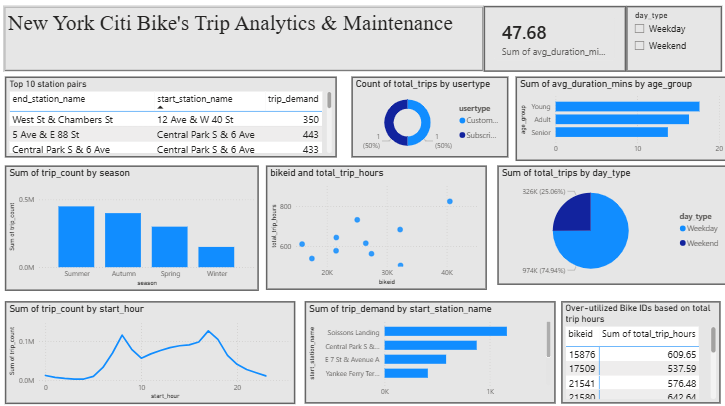


# **Dashboard Insights & Business Interpretation**

1. Temporal Analysis (Demand Patterns):Hourly Demand Profile: The line chart reveals a distinct, classic bimodal "M-curve" commuter pattern. Peak usage heavily concentrates during morning rush hour (roughly 7:00 AM – 9:00 AM) and evening rush hour (4:00 PM – 6:00 PM).  Day Type Variations & Seasonal Trends: Weekday trips dominate the system volume at 74.94% compared to 25.06% on Weekends. While average travel distances stay highly consistent across day types ($\approx 1.76\text{ km}$ to $1.81\text{ km}$), the quarterly trip volume column chart shows a steep drops in ridership during the Winter season compared to Peak Summer demand.  

2. Infrastructure & Station Analysis:High-Demand Hubs & Top Station Pairs: Soissons Landing and Central Park S & 6 Ave stand out as the highest volume individual start locations. Additionally, the top station pairs matrix identifies high-density commuting corridors, such as the route from 12 Ave & W 40 St to West St & Chambers St, which handles concentrated, repetitive trip demand.  Strategic Recommendation: The city planning agency should prioritize adding dock capacities and targeted bike rebalancing schedules at these specific high-volume hubs and corridors to avoid localized system depletion during peak hours.  

3. Operations & Asset Maintenance Alert:Critical Assets & Utilization Distribution: The asset tracking matrix flags heavy utilization concentrated on a small inventory of 10 distinct bikes. The scatter plot reveals a broad distribution of total trip hours, highlighting severe wear on Bike ID 40515 at 823.39 hours and Bike ID 25073 at 731.21 hours.  Actionable Maintenance Plan: These heavily utilized units must be proactively flagged and pulled for immediate mechanical inspections to minimize potential on-road equipment failures.  